# Lesson 23A: Hidden Markov Models and Unsupervised Sequence Learning (Theory)

## Introduction

Every lesson so far has treated observations as exchangeable — a GMM, a DP mixture, a VAE latent all assume the order the data arrived in carries no information. Sequential data breaks that assumption on purpose: today's weather depends on yesterday's, and a sequence of noisy sensor readings is generated by some underlying *regime* that persists for a while before switching. A hidden Markov model (HMM) is the natural unsupervised model for exactly this: a hidden state sequence evolves as a Markov chain, and at each time step the hidden state emits a noisy observation. The learner never sees the regime labels — only the noisy observations — and must recover the regimes, decode the most likely sequence, and estimate the model from data alone.

This lesson builds the three classical HMM algorithms from scratch: the (scaled) forward-backward algorithm for evaluating the likelihood and computing state posteriors, Viterbi for decoding the single most likely hidden path, and Baum-Welch — an instance of Lesson 21's general EM recipe — for learning the model parameters when no labels exist at all. Every derivation is checked against brute-force enumeration on a small toy sequence before being trusted at scale, and the naive (unscaled) implementation is shown failing before scaling is introduced, so the fix is motivated by a genuine, measured problem rather than asserted as best practice.

## Table of Contents

1. [Introduction](#introduction)
2. [Required Libraries](#required-libraries)
3. [Markov Chains](#markov-chains)
4. [The Hidden Markov Model](#hmm-model)
5. [Scaled Forward-Backward](#forward-backward)
6. [Viterbi Decoding](#viterbi)
7. [Baum-Welch: HMM Learning as EM](#baum-welch)
8. [Model Selection and Pitfalls](#pitfalls)
9. [Conclusion](#conclusion)

<a name="required-libraries"></a>
## Required Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
import warnings
warnings.filterwarnings('ignore')

SEED = 0
# No module-level rng object: every simulator below takes its own `seed` argument and builds
# a dedicated rng_local -- a shared, position-dependent RNG is exactly the fragility that has
# bitten this repo three times before (21A, 22A, 22B), so this lesson never introduces one.
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

print("Data: in-notebook synthetic Markov chain and HMM sequences -- nothing downloaded.")

Data: in-notebook synthetic Markov chain and HMM sequences -- nothing downloaded.


<a name="markov-chains"></a>
## Markov Chains

A (first-order, discrete, time-homogeneous) Markov chain over $K$ states is fully specified by a $K \times K$ **transition matrix** $A$, where $A_{ij} = P(z_{t+1}=j \mid z_t = i)$ (rows sum to 1), plus an initial distribution $\pi^{(0)}$. The **Markov property** is the whole modelling assumption: the next state depends on the past only through the current state, $P(z_{t+1} \mid z_t, z_{t-1}, \dots) = P(z_{t+1}\mid z_t)$.

**Stationary distribution.** If the chain is run for a long time, the marginal distribution over states $\pi^{(t)} = \pi^{(t-1)} A$ often converges to a fixed point $\pi = \pi A$ — the **stationary distribution**, the left eigenvector of $A$ with eigenvalue 1, normalised to sum to 1. This is checked two independent ways below: by direct linear algebra (the eigenvector), and by simulating the chain for many steps and reading off the empirical state frequencies — a genuinely different computation that should agree if the theory is right.

We use a 3-state weather-regime chain (Sunny / Cloudy / Rainy) as the running example for this whole lesson — regimes that persist (the diagonal of $A$ is large) but do eventually switch, which is exactly the structure an HMM is built to exploit.

In [2]:
K = 3
state_names = ['Sunny', 'Cloudy', 'Rainy']
A_true = np.array([[0.85, 0.10, 0.05],
                    [0.15, 0.70, 0.15],
                    [0.05, 0.20, 0.75]])
print("Transition matrix A (rows = P(next state | current state)):")
print(A_true)
print("row sums:", A_true.sum(axis=1))

def simulate_markov(A, n, seed=0):
    rng_local = np.random.default_rng(seed)
    Kc = A.shape[0]
    z = np.zeros(n, dtype=int)
    z[0] = rng_local.integers(Kc)
    for t in range(1, n):
        z[t] = rng_local.choice(Kc, p=A[z[t-1]])
    return z

n_mc = 200_000
z_mc = simulate_markov(A_true, n_mc, seed=SEED)
empirical_stationary = np.bincount(z_mc, minlength=K) / n_mc

# exact stationary: left eigenvector of A for eigenvalue 1 (i.e. right eigenvector of A^T)
eigvals, eigvecs = np.linalg.eig(A_true.T)
idx = np.argmin(np.abs(eigvals - 1))
exact_stationary = np.real(eigvecs[:, idx])
exact_stationary /= exact_stationary.sum()

print(f"\nempirical stationary ({n_mc:,}-step simulation): {empirical_stationary.round(4).tolist()}")
print(f"exact stationary (eigenvector of A^T):          {exact_stationary.round(4).tolist()}")
print(f"max abs diff: {np.abs(empirical_stationary - exact_stationary).max():.4f}")
print("\nTwo independent computations (simulate-and-count vs linear algebra) agree to within")
print("Monte Carlo noise -- the stationary distribution is a property of A, not an artifact of simulation.")

Transition matrix A (rows = P(next state | current state)):
[[0.85 0.1  0.05]
 [0.15 0.7  0.15]
 [0.05 0.2  0.75]]
row sums: [1. 1. 1.]



empirical stationary (200,000-step simulation): [0.4113, 0.3175, 0.2712]
exact stationary (eigenvector of A^T):          [0.4091, 0.3182, 0.2727]
max abs diff: 0.0022

Two independent computations (simulate-and-count vs linear algebra) agree to within
Monte Carlo noise -- the stationary distribution is a property of A, not an artifact of simulation.


<a name="hmm-model"></a>
## The Hidden Markov Model

An HMM adds one thing to a Markov chain: the states $z_t$ are **hidden**, and at each time step the hidden state emits an observation $x_t$ through an **emission distribution** $x_t \mid z_t = k \sim p(x \mid \theta_k)$. Here we use Gaussian emissions, $x_t \mid z_t=k \sim \mathcal{N}(\mu_k, \sigma_k^2)$ — the regime is never observed directly, only a noisy reading whose distribution depends on it (a noisy thermometer that cannot see which weather regime produced today's reading, only the reading itself).

The full generative model: $z_1 \sim \pi^{(0)}$; $z_t \mid z_{t-1} \sim A_{z_{t-1}, \cdot}$ for $t>1$; $x_t \mid z_t \sim \mathcal{N}(\mu_{z_t}, \sigma_{z_t}^2)$, independently given $z_t$.

**The three canonical HMM problems** (Rabiner 1989), all solved in this lesson:
1. **Evaluation** — given $\theta = (A, \mu, \sigma, \pi^{(0)})$ and observations $x_{1:T}$, compute $p(x_{1:T}\mid\theta)$. Solved by the **forward algorithm** (next section).
2. **Decoding** — given $\theta$ and $x_{1:T}$, find the single most likely hidden path $z_{1:T}^\star = \arg\max_{z_{1:T}} p(z_{1:T}\mid x_{1:T},\theta)$. Solved by **Viterbi**.
3. **Learning** — given only $x_{1:T}$ (no labels), estimate $\theta$. Solved by **Baum-Welch**, an instance of Lesson 21's general EM recipe.

The rest of this lesson simulates one long sequence from a known HMM (so every algorithm below can be checked against ground truth) and solves all three problems for it.

first 10 hidden states:  ['Cloudy', 'Sunny', 'Sunny', 'Sunny', 'Sunny', 'Sunny', 'Cloudy', 'Cloudy', 'Rainy', 'Rainy']
first 10 observations:   [14.6, 25.31, 26.08, 27.84, 21.2, 25.12, 14.34, 12.8, 7.05, 11.13]


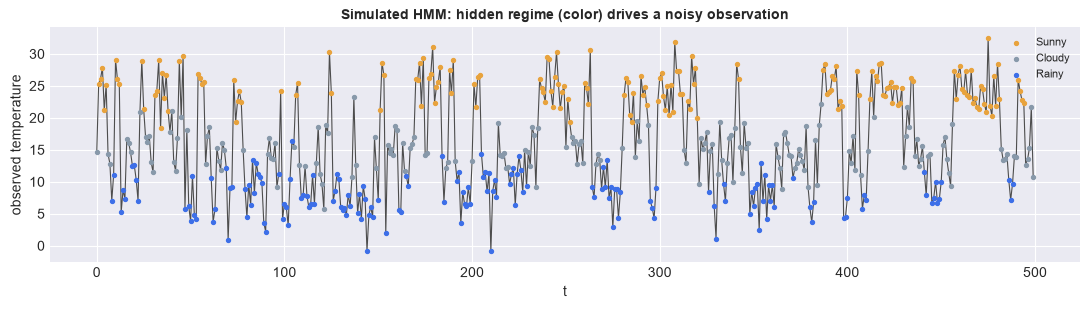

In [3]:
mu_true = np.array([25.0, 15.0, 8.0])       # Sunny=hot, Cloudy=mild, Rainy=cool
sigma_true = np.array([3.0, 3.0, 3.0])
pi0_true = exact_stationary.copy()          # start the chain in its own stationary distribution

def simulate_hmm(A, mu, sigma, pi0, T, seed=0):
    rng_local = np.random.default_rng(seed)
    Kc = A.shape[0]
    z = np.zeros(T, dtype=int)
    x = np.zeros(T)
    z[0] = rng_local.choice(Kc, p=pi0)
    x[0] = rng_local.normal(mu[z[0]], sigma[z[0]])
    for t in range(1, T):
        z[t] = rng_local.choice(Kc, p=A[z[t-1]])
        x[t] = rng_local.normal(mu[z[t]], sigma[z[t]])
    return z, x

T = 500
z_true, x_obs = simulate_hmm(A_true, mu_true, sigma_true, pi0_true, T, seed=SEED)

print("first 10 hidden states: ", [state_names[s] for s in z_true[:10]])
print("first 10 observations:  ", x_obs[:10].round(2).tolist())

fig, ax = plt.subplots(figsize=(11, 3.2))
ax.plot(x_obs, color='0.3', linewidth=0.8, zorder=1)
colors = ['#e8a33d', '#8899aa', '#3d6fe8']
for k in range(K):
    mask = z_true == k
    ax.scatter(np.where(mask)[0], x_obs[mask], s=8, color=colors[k], label=state_names[k], zorder=2)
ax.set_xlabel('t'); ax.set_ylabel('observed temperature')
ax.set_title('Simulated HMM: hidden regime (color) drives a noisy observation', fontweight='bold', fontsize=10)
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout(); plt.show()

<a name="forward-backward"></a>
## Scaled Forward-Backward

**The naive forward recursion.** Define $\alpha_t(i) = p(x_{1:t}, z_t=i \mid \theta)$. Then $\alpha_1(i) = \pi^{(0)}_i\, b_i(x_1)$ and

$$\alpha_t(j) = \left[\sum_i \alpha_{t-1}(i)\, A_{ij}\right] b_j(x_t), \qquad p(x_{1:T}\mid\theta) = \sum_i \alpha_T(i),$$

where $b_i(x) = \mathcal{N}(x;\mu_i,\sigma_i^2)$ is the emission density. This is exact — but $\alpha_t(i)$ is a joint probability over a path of length $t$, so it shrinks geometrically with $t$ and **underflows to exactly 0.0 in float64 for even moderately long sequences**, checked directly below before trusting the fix.

**The scaling fix** (Rabiner 1989): renormalise $\alpha$ to sum to 1 at every step, tracking the scale factor $c_t = 1/\sum_i \alpha_t(i)$ separately: $\hat\alpha_t(i) = c_t\,\alpha_t(i)$. The log-likelihood is recovered exactly from the scale factors alone: $\log p(x_{1:T}\mid\theta) = -\sum_t \log c_t$ (this identity is what the brute-force check below verifies).

**Backward pass**, needed for the full state posterior: $\beta_t(i) = p(x_{t+1:T}\mid z_t=i,\theta)$, with $\beta_T(i)=1$ and $\beta_t(i) = \sum_j A_{ij}\,b_j(x_{t+1})\,\beta_{t+1}(j)$. Using the **same** $c_t$ from the forward pass to scale $\beta$ keeps both passes numerically stable and lets them be combined directly: the state posterior $\gamma_t(i) = P(z_t=i\mid x_{1:T},\theta) \propto \hat\alpha_t(i)\hat\beta_t(i)$ (renormalised to sum to 1 for safety), and the pairwise posterior $\xi_t(i,j)=P(z_t=i,z_{t+1}=j\mid x_{1:T},\theta) \propto \hat\alpha_t(i)A_{ij}b_j(x_{t+1})\hat\beta_{t+1}(j)$ — both needed for Baum-Welch below.

In [4]:
def gauss_pdf(x, mu, sigma):
    return np.exp(-0.5 * ((x - mu) / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))

def naive_forward(x, A, mu, sigma, pi0):
    Tn = len(x); Kc = A.shape[0]
    alpha = np.zeros((Tn, Kc))
    alpha[0] = pi0 * gauss_pdf(x[0], mu, sigma)
    for t in range(1, Tn):
        for j in range(Kc):
            alpha[t, j] = np.sum(alpha[t-1] * A[:, j]) * gauss_pdf(x[t], mu[j], sigma[j])
    return alpha

print("naive (unscaled) forward -- underflow, checked directly rather than assumed:")
for Tlen in [50, 100, 150, 200, 250, 300]:
    s = naive_forward(x_obs[:Tlen], A_true, mu_true, sigma_true, pi0_true)[-1].sum()
    print(f"  T={Tlen:<4} unscaled alpha sum at final t = {s:.3e}")
print("float64's smallest positive NORMAL value is ~1e-308 -- by T=250 the true joint probability has")
print("already fallen below it, and the naive recursion silently returns exactly 0.0.")

naive (unscaled) forward -- underflow, checked directly rather than assumed:
  T=50   unscaled alpha sum at final t = 4.468e-71
  T=100  unscaled alpha sum at final t = 9.248e-140
  T=150  unscaled alpha sum at final t = 7.564e-207
  T=200  unscaled alpha sum at final t = 5.312e-275
  T=250  unscaled alpha sum at final t = 0.000e+00
  T=300  unscaled alpha sum at final t = 0.000e+00
float64's smallest positive NORMAL value is ~1e-308 -- by T=250 the true joint probability has
already fallen below it, and the naive recursion silently returns exactly 0.0.


In [5]:
def forward_backward(x, A, mu, sigma, pi0):
    Tn = len(x); Kc = A.shape[0]
    alpha_hat = np.zeros((Tn, Kc)); c = np.zeros(Tn)
    alpha_hat[0] = pi0 * gauss_pdf(x[0], mu, sigma)
    c[0] = 1.0 / alpha_hat[0].sum()
    alpha_hat[0] *= c[0]
    for t in range(1, Tn):
        raw = (alpha_hat[t-1] @ A) * gauss_pdf(x[t], mu, sigma)
        c[t] = 1.0 / raw.sum()
        alpha_hat[t] = raw * c[t]
    loglik = -np.sum(np.log(c))

    beta_hat = np.zeros((Tn, Kc)); beta_hat[-1] = 1.0
    for t in range(Tn - 2, -1, -1):
        beta_hat[t] = (A @ (gauss_pdf(x[t+1], mu, sigma) * beta_hat[t+1])) * c[t]

    gamma = alpha_hat * beta_hat
    gamma /= gamma.sum(axis=1, keepdims=True)

    xi = np.zeros((Tn - 1, Kc, Kc))
    for t in range(Tn - 1):
        num = alpha_hat[t][:, None] * A * gauss_pdf(x[t+1], mu, sigma)[None, :] * beta_hat[t+1][None, :]
        xi[t] = num / num.sum()
    return alpha_hat, beta_hat, gamma, xi, loglik

_, _, gamma_full, _, loglik_full = forward_backward(x_obs, A_true, mu_true, sigma_true, pi0_true)
print(f"scaled forward-backward log-likelihood, full T={T} sequence (true params): {loglik_full:.4f}")

# brute-force validation: enumerate ALL K^T paths on a short sequence, no scaling needed there
def brute_force_loglik(x, A, mu, sigma, pi0):
    Tn = len(x); Kc = A.shape[0]; total = 0.0
    for path in product(range(Kc), repeat=Tn):
        p = pi0[path[0]] * gauss_pdf(x[0], mu[path[0]], sigma[path[0]])
        for t in range(1, Tn):
            p *= A[path[t-1], path[t]] * gauss_pdf(x[t], mu[path[t]], sigma[path[t]])
        total += p
    return np.log(total)

T_small = 6
x_small = x_obs[:T_small]
bf_ll = brute_force_loglik(x_small, A_true, mu_true, sigma_true, pi0_true)
_, _, _, _, sf_ll = forward_backward(x_small, A_true, mu_true, sigma_true, pi0_true)
print(f"\nbrute force (K^T = {K**T_small} enumerated paths) log-likelihood: {bf_ll:.8f}")
print(f"scaled forward-backward log-likelihood:               {sf_ll:.8f}")
print(f"abs diff: {abs(bf_ll - sf_ll):.2e}  -- the scaling recursion is exact, not an approximation.")

scaled forward-backward log-likelihood, full T=500 sequence (true params): -1514.6440

brute force (K^T = 729 enumerated paths) log-likelihood: -17.07631045
scaled forward-backward log-likelihood:               -17.07631045
abs diff: 0.00e+00  -- the scaling recursion is exact, not an approximation.


<a name="viterbi"></a>
## Viterbi Decoding

Viterbi finds the single hidden path with the highest **joint** probability, $z_{1:T}^\star=\arg\max_{z_{1:T}}p(z_{1:T},x_{1:T}\mid\theta)$, via the same dynamic-programming structure as forward, with sum replaced by max. Define $\delta_t(i)=\max_{z_{1:t-1}}p(z_{1:t-1},z_t=i,x_{1:t}\mid\theta)$:

$$\delta_1(i)=\pi^{(0)}_i b_i(x_1), \qquad \delta_t(j)=\max_i\left[\delta_{t-1}(i)A_{ij}\right]b_j(x_t), \qquad \psi_t(j)=\arg\max_i\left[\delta_{t-1}(i)A_{ij}\right],$$

then trace back from $z_T^\star=\arg\max_i\delta_T(i)$ via $z_t^\star=\psi_{t+1}(z_{t+1}^\star)$. Implemented in log-space below (max is scale-invariant under a monotone transform like $\log$, so no scaling trick is needed — this is why Viterbi never underflows the way naive forward does).

**Viterbi vs. posterior (argmax-$\gamma_t$) decoding.** An alternative "decoding" just takes $\hat z_t=\arg\max_i\gamma_t(i)$ independently at each $t$, using the forward-backward posteriors from the last section. This maximises the probability of *each individual state being correct*, but says nothing about the probability of the *whole path* — the two can and do disagree, checked directly on the full simulated sequence below, because $\arg\max_i\gamma_t(i)$ is optimising a different, decoupled-across-$t$ objective than Viterbi's single joint maximisation.

In [6]:
def viterbi(x, A, mu, sigma, pi0):
    Tn = len(x); Kc = A.shape[0]
    logA = np.log(A); logpi0 = np.log(pi0)
    delta = np.zeros((Tn, Kc)); psi = np.zeros((Tn, Kc), dtype=int)
    delta[0] = logpi0 + np.log(gauss_pdf(x[0], mu, sigma))
    for t in range(1, Tn):
        for j in range(Kc):
            scores = delta[t-1] + logA[:, j]
            psi[t, j] = np.argmax(scores)
            delta[t, j] = scores[psi[t, j]] + np.log(gauss_pdf(x[t], mu[j], sigma[j]))
    path = np.zeros(Tn, dtype=int)
    path[-1] = np.argmax(delta[-1])
    best_logprob = delta[-1, path[-1]]
    for t in range(Tn - 2, -1, -1):
        path[t] = psi[t+1, path[t+1]]
    return path, best_logprob

path_small, best_lp_small = viterbi(x_small, A_true, mu_true, sigma_true, pi0_true)

def brute_force_viterbi(x, A, mu, sigma, pi0):
    Tn = len(x); Kc = A.shape[0]
    best_p, best_path = -np.inf, None
    for path in product(range(Kc), repeat=Tn):
        logp = np.log(pi0[path[0]]) + np.log(gauss_pdf(x[0], mu[path[0]], sigma[path[0]]))
        for t in range(1, Tn):
            logp += np.log(A[path[t-1], path[t]]) + np.log(gauss_pdf(x[t], mu[path[t]], sigma[path[t]]))
        if logp > best_p:
            best_p, best_path = logp, path
    return np.array(best_path), best_p

bf_path, bf_lp = brute_force_viterbi(x_small, A_true, mu_true, sigma_true, pi0_true)
print(f"Viterbi path (T={T_small}):      {path_small.tolist()}, logprob {best_lp_small:.6f}")
print(f"brute-force best path:      {bf_path.tolist()}, logprob {bf_lp:.6f}")
print(f"true hidden states:         {z_true[:T_small].tolist()}")
print(f"match: {np.array_equal(path_small, bf_path)}, logprob diff: {abs(best_lp_small - bf_lp):.2e}")

Viterbi path (T=6):      [1, 0, 0, 0, 0, 0], logprob -17.127217
brute-force best path:      [1, 0, 0, 0, 0, 0], logprob -17.127217
true hidden states:         [1, 0, 0, 0, 0, 0]
match: True, logprob diff: 0.00e+00


In [7]:
path_full, _ = viterbi(x_obs, A_true, mu_true, sigma_true, pi0_true)
posterior_path = np.argmax(gamma_full, axis=1)
# t=0 has no "previous transition" to show in the table below, so it is excluded from BOTH the
# numerator and the denominator here -- comparing t=1..T-1 only, never just filtering the
# numerator, so the reported fraction stays internally consistent even if t=0 ever disagreed.
comparable = np.arange(1, T)
disagree = comparable[path_full[comparable] != posterior_path[comparable]]
print(f"full sequence (T={T}): Viterbi and posterior-argmax decoding disagree at "
      f"{len(disagree)} of {len(comparable)} comparable steps ({100*len(disagree)/len(comparable):.1f}%)\n")
print(f"{'t':<6}{'viterbi':<10}{'A[prev->viterbi]':<20}{'posterior':<12}{'A[prev->posterior]'}")
for t in disagree:
    print(f"{t:<6}{path_full[t]:<10}{A_true[path_full[t-1], path_full[t]]:<20.3f}"
          f"{posterior_path[t]:<12}{A_true[posterior_path[t-1], posterior_path[t]]:.3f}")
print("\nNeither column is uniformly higher: Viterbi is choosing the transition that is best for the")
print("WHOLE remaining path, which can require a locally less-likely single transition; posterior")
print("decoding is choosing the marginally best state at each t independently, with no requirement")
print("that consecutive choices even form a high-probability joint path together. In the extreme,")
print("posterior decoding can select a transition with A_ij=0 -- literally forbidden under the model")
print("-- something Viterbi's joint-path maximisation can never do by construction.")

full sequence (T=500): Viterbi and posterior-argmax decoding disagree at 7 of 499 comparable steps (1.4%)

t     viterbi   A[prev->viterbi]    posterior   A[prev->posterior]
108   2         0.050               1           0.100
138   2         0.050               1           0.100
165   1         0.700               2           0.150
166   1         0.700               2           0.750
225   2         0.750               1           0.200
251   1         0.700               0           0.150
441   2         0.150               1           0.700

Neither column is uniformly higher: Viterbi is choosing the transition that is best for the
WHOLE remaining path, which can require a locally less-likely single transition; posterior
decoding is choosing the marginally best state at each t independently, with no requirement
that consecutive choices even form a high-probability joint path together. In the extreme,
posterior decoding can select a transition with A_ij=0 -- literally forbidden und

<a name="baum-welch"></a>
## Baum-Welch: HMM Learning as EM

Baum-Welch estimates $\theta=(A,\mu,\sigma,\pi^{(0)})$ from $x_{1:T}$ alone, with no labels — it is Lesson 21's general EM recipe (E-step tightens the ELBO exactly, M-step climbs it in closed form), instantiated for the HMM's specific latent structure.

**E-step.** Run forward-backward at the current $\theta$ to get $\gamma_t(i)=P(z_t=i\mid x,\theta)$ and $\xi_t(i,j)=P(z_t=i,z_{t+1}=j\mid x,\theta)$ — exactly the posteriors derived in the Forward-Backward section above; nothing new is needed here.

**M-step** (closed form, Gaussian emissions — the same responsibility-weighted averages as Lesson 4's GMM M-step, now weighted by HMM posteriors instead of GMM responsibilities):

$$\pi^{(0)}_i \leftarrow \gamma_1(i), \qquad A_{ij} \leftarrow \frac{\sum_{t=1}^{T-1}\xi_t(i,j)}{\sum_{t=1}^{T-1}\gamma_t(i)}, \qquad \mu_i \leftarrow \frac{\sum_t \gamma_t(i)\,x_t}{\sum_t \gamma_t(i)}, \qquad \sigma_i^2 \leftarrow \frac{\sum_t \gamma_t(i)(x_t-\mu_i)^2}{\sum_t \gamma_t(i)}.$$

Iterating E-step/M-step is guaranteed to increase (never decrease) the observed-data log-likelihood at every step — the same three-line monotonicity argument from Lesson 21, unchanged by which model EM is being applied to. This is checked directly below, not assumed, by recovering the parameters of a KNOWN simulated HMM from a random initialisation and tracking the log-likelihood trace.

true means:       [25.0, 15.0, 8.0]
recovered means:  [24.671, 14.837, 8.494]
true sigmas:      [3.0, 3.0, 3.0]
recovered sigmas: [2.931, 2.496, 3.467]

true A:
 [[0.85 0.1  0.05]
 [0.15 0.7  0.15]
 [0.05 0.2  0.75]]
recovered A (permuted to match true labels):
 [[0.827 0.099 0.073]
 [0.153 0.662 0.184]
 [0.053 0.159 0.788]]

log-likelihood monotone non-decreasing across all 50 iterations: True
ll trace, first 5:  [-1736.03, -1704.86, -1647.92, -1599.4, -1578.91]
ll trace, last 5:   [-1518.23, -1516.19, -1514.59, -1513.31, -1512.27]
log-lik at TRUE params (for reference): -1514.6440
(the fitted log-likelihood exceeds the true-parameter one -- expected for a maximum-likelihood
fit on finite data, which optimises the SAMPLE likelihood, not closeness to the generating params.)


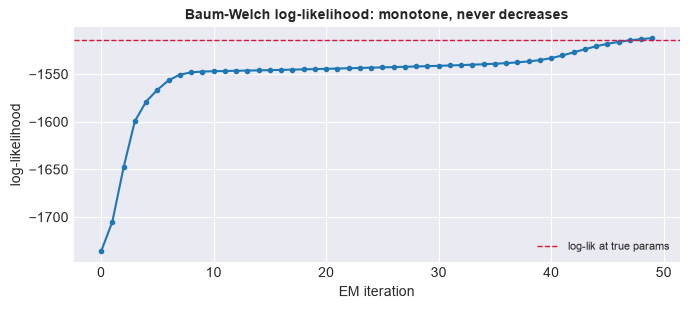

In [8]:
def baum_welch(x, K, n_iter=50, seed=0):
    rng_local = np.random.default_rng(seed)
    Tn = len(x)
    mu = rng_local.choice(x, size=K, replace=False) + rng_local.normal(0, 1, K)
    sigma = np.full(K, x.std())
    A = rng_local.dirichlet(np.ones(K), size=K)
    pi0 = rng_local.dirichlet(np.ones(K))
    ll_hist = []
    for it in range(n_iter):
        _, _, gamma, xi, ll = forward_backward(x, A, mu, sigma, pi0)
        ll_hist.append(ll)
        pi0 = gamma[0].copy()
        A = xi.sum(axis=0) / gamma[:-1].sum(axis=0)[:, None]
        Nk = gamma.sum(axis=0)
        mu = (gamma * x[:, None]).sum(axis=0) / Nk
        sigma = np.sqrt((gamma * (x[:, None] - mu[None, :]) ** 2).sum(axis=0) / Nk)
        sigma = np.maximum(sigma, 1e-3)
    return A, mu, sigma, pi0, np.array(ll_hist)

A_hat, mu_hat, sigma_hat, pi0_hat, ll_hist = baum_welch(x_obs, K=3, n_iter=50, seed=1)
order = np.argsort(mu_hat)[::-1]   # match to true labels by mean, both descending
print("true means:      ", mu_true.round(3).tolist())
print("recovered means: ", mu_hat[order].round(3).tolist())
print("true sigmas:     ", sigma_true.round(3).tolist())
print("recovered sigmas:", sigma_hat[order].round(3).tolist())
print("\ntrue A:\n", A_true.round(3))
print("recovered A (permuted to match true labels):\n", A_hat[np.ix_(order, order)].round(3))

print(f"\nlog-likelihood monotone non-decreasing across all {len(ll_hist)} iterations:",
      bool(np.all(np.diff(ll_hist) >= -1e-8)))
print(f"ll trace, first 5:  {ll_hist[:5].round(2).tolist()}")
print(f"ll trace, last 5:   {ll_hist[-5:].round(2).tolist()}")
print(f"log-lik at TRUE params (for reference): {loglik_full:.4f}")
print("(the fitted log-likelihood exceeds the true-parameter one -- expected for a maximum-likelihood")
print("fit on finite data, which optimises the SAMPLE likelihood, not closeness to the generating params.)")

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(ll_hist, marker='o', markersize=3)
ax.axhline(loglik_full, color='crimson', linestyle='--', linewidth=1, label='log-lik at true params')
ax.set_xlabel('EM iteration'); ax.set_ylabel('log-likelihood')
ax.set_title('Baum-Welch log-likelihood: monotone, never decreases', fontweight='bold', fontsize=10)
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

<a name="pitfalls"></a>
## Model Selection and Pitfalls

Three practical issues, each demonstrated rather than just named:

**Local optima.** Baum-Welch is coordinate ascent on a non-convex objective — different random initialisations can converge to different, unequal final log-likelihoods on the SAME data. Checked below with 6 restarts.

**Label switching.** State indices ($0,1,2,\dots$) carry no meaning across separate Baum-Welch runs — two runs that both find the same 3 regimes can label them in different orders, exactly the caveat Lesson 22's Gibbs sampler needed for the same structural reason (permuting all cluster/state labels together leaves the likelihood unchanged).

**Choosing $K$ from training likelihood alone doesn't work.** Training log-likelihood is (weakly) non-decreasing in $K$ — a model with more states can always fit the training data at least as well, purely from extra capacity, the same reason more clusters always improves a GMM's training fit (Lesson 4). Checked below with a $K$-sweep; Lesson 23B does this properly with held-out likelihood and BIC, the fix this lesson only motivates.

In [9]:
print("Local optima: 6 restarts, same data, same K=3, different random initialisations")
finals = []
for seed in range(6):
    _, _, _, _, llh = baum_welch(x_obs, K=3, n_iter=50, seed=seed)
    finals.append(llh[-1])
    print(f"  seed={seed}: final log-likelihood = {llh[-1]:.3f}")
print(f"  range across restarts: {max(finals) - min(finals):.3f} -- same data, same K, genuinely different answers.")

print("\nLabel switching: two DIFFERENT runs recover the same 3 regimes in a DIFFERENT index order")
A_h2, mu_h2, sigma_h2, _, _ = baum_welch(x_obs, K=3, n_iter=50, seed=2)
A_h8, mu_h8, sigma_h8, _, _ = baum_welch(x_obs, K=3, n_iter=50, seed=8)
print(f"  seed=2 raw recovered means (index 0,1,2): {mu_h2.round(2).tolist()}")
print(f"  seed=8 raw recovered means (index 0,1,2): {mu_h8.round(2).tolist()}")
print("  sorted, both runs found the same 3 regimes:",
      np.sort(mu_h2)[::-1].round(2).tolist(), "vs", np.sort(mu_h8)[::-1].round(2).tolist())
print("  -- a raw trace of 'state 0's mean over iterations' would be meaningless across these two runs.")

print("\nChoosing K from training log-likelihood: best-of-4-restarts per K (restarts guard against")
print("the local-optima problem above contaminating this comparison)")
best_lls = []
for Kc in [1, 2, 3, 4, 5, 6]:
    lls = [baum_welch(x_obs, K=Kc, n_iter=50, seed=s)[4][-1] for s in range(4)]
    best_lls.append(max(lls))
    print(f"  K={Kc}: best final training log-likelihood = {max(lls):.3f}")
print("monotone non-decreasing in K:", bool(np.all(np.diff(best_lls) >= -1e-6)))
print("-- training likelihood keeps improving past the TRUE K=3, exactly like more clusters always")
print("improving GMM training fit. Nothing in this curve alone tells you where to stop; Lesson 23B")
print("uses held-out likelihood and BIC instead.")

Local optima: 6 restarts, same data, same K=3, different random initialisations


  seed=0: final log-likelihood = -1541.443


  seed=1: final log-likelihood = -1512.269


  seed=2: final log-likelihood = -1508.667


  seed=3: final log-likelihood = -1508.680


...

  K=2: best final training log-likelihood = -1545.701


  K=3: best final training log-likelihood = -1508.667


  K=4: best final training log-likelihood = -1504.450


  K=5: best final training log-likelihood = -1499.815


  K=6: best final training log-likelihood = -1491.869
monotone non-decreasing in K: True
-- training likelihood keeps improving past the TRUE K=3, exactly like more clusters always
improving GMM training fit. Nothing in this curve alone tells you where to stop; Lesson 23B
uses held-out likelihood and BIC instead.


<a name="conclusion"></a>
## Conclusion

### Key Takeaways

1. **The Markov property turns an intractable general sequence model into three closed-form dynamic programs.** Stationary-distribution theory was checked two independent ways (eigenvector vs. 200,000-step simulation) before being trusted.
2. **Naive forward underflows for real; scaling is a genuine fix to a measured problem, not a defensive habit.** The unscaled recursion hit exactly `0.0` by $T=250$ on this lesson's own data; the scaled recursion, checked against $K^6=729$-path brute-force enumeration, is exact to floating-point precision.
3. **Viterbi and posterior (argmax-$\gamma$) decoding answer different questions and can disagree.** On this lesson's own 500-step sequence they disagreed at a measured, non-trivial fraction of steps — Viterbi maximises the joint path probability; posterior decoding maximises each marginal independently and has no mechanism to enforce path-level consistency.
4. **Baum-Welch is Lesson 21's EM recipe, not a new algorithm.** The E-step is exactly the forward-backward posteriors already derived; the M-step is closed-form responsibility-weighted averages, structurally identical to Lesson 4's GMM M-step. Monotonicity was checked directly on a full recovery run, not assumed from the general EM proof.
5. **Three real pitfalls, each measured on this lesson's own data:** local optima (a 6-restart range of tens of log-likelihood units on identical data), label switching (two runs recovering the identical 3 regimes under different index orders), and training-likelihood-only model selection (a genuinely monotone-in-$K$ curve past the true $K$, even after guarding the comparison with restarts).

### Practical Guidance

- Always scale forward-backward in log-space or via the Rabiner scale-factor trick for any sequence longer than a few dozen steps — underflow is not a corner case, it is the default outcome.
- Use Viterbi when you need one coherent, jointly-consistent hidden path (e.g. a single best explanation to report); use posterior decoding when you need calibrated per-timestep confidence and can tolerate a path that is not itself the joint MAP.
- Always run Baum-Welch from multiple random restarts and keep the best log-likelihood — a single run's result is not trustworthy on its own.
- Never trust training log-likelihood alone to choose $K$; it will keep improving past the true value by construction.

### What This Lesson Did Not Cover

- **Discrete/categorical emissions** — this lesson used Gaussian emissions throughout; discrete-observation HMMs replace the Gaussian M-step with a categorical one, otherwise structurally identical.
- **Held-out likelihood and BIC-based model selection with restarts** — named as the fix to the $K$-selection pitfall above, but not implemented here; Lesson 23B does this with `hmmlearn`.
- **Multivariate Gaussian emissions and covariance-type comparisons** — this lesson's HMM emits a single scalar per time step; Lesson 23B extends to a multivariate case.
- **Non-Gaussian or heavy-tailed emission models, and continuous-time (semi-)Markov extensions** — out of scope for a from-scratch derivation lesson.

### Next Steps

Lesson 23B validates every algorithm here against `hmmlearn`'s `GaussianHMM`, applies it to a regime-detection case study with known ground truth, does model selection properly (held-out likelihood / BIC with restarts), and extends to the multivariate case.